In [8]:
import brian2
import yaml

In [9]:
with open('neuron_models.yaml', 'r') as f:
    eqs = yaml.load(f)['Spencer2009_neuron']['eqs']


WARNING    /home/yi/.local/lib/python3.6/site-packages/ipykernel_launcher.py:2: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  
 [py.warnings]


In [10]:
with open('neuron_parameters.yaml', 'r') as f:
    params = yaml.load(f)['Pyramidal_Cells']

WARNING    /home/yi/.local/lib/python3.6/site-packages/ipykernel_launcher.py:2: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  
 [py.warnings]


In [11]:
params['namespace'] = dict((name, eval(quantity, brian2.core.namespace.DEFAULT_UNITS)) for name, quantity in params['namespace'].items())
params.pop('eqs')

'Spencer2009_neuron'

In [12]:
params['namespace']

{'g_m': 25. * nsiemens,
 'C_m': 0.5 * nfarad,
 'V_res': -70. * mvolt,
 'V_E': 0. * volt,
 'V_I': -70. * mvolt,
 'C_Mg': 1.0}

In [13]:
brian2.start_scope()
G = brian2.NeuronGroup(3, eqs, **params)

INFO       No numerical integration method specified for group 'neurongroup_1', using method 'exact' (took 0.36s). [brian2.stateupdaters.base.method_choice]


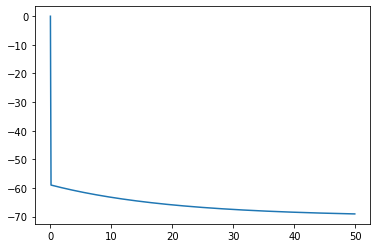

In [14]:
M = brian2.StateMonitor(G, 'V', record=0)
brian2.run(50*brian2.ms)
import matplotlib.pyplot as plt
plt.plot(M.t/brian2.ms, M.V[0]/brian2.mV)